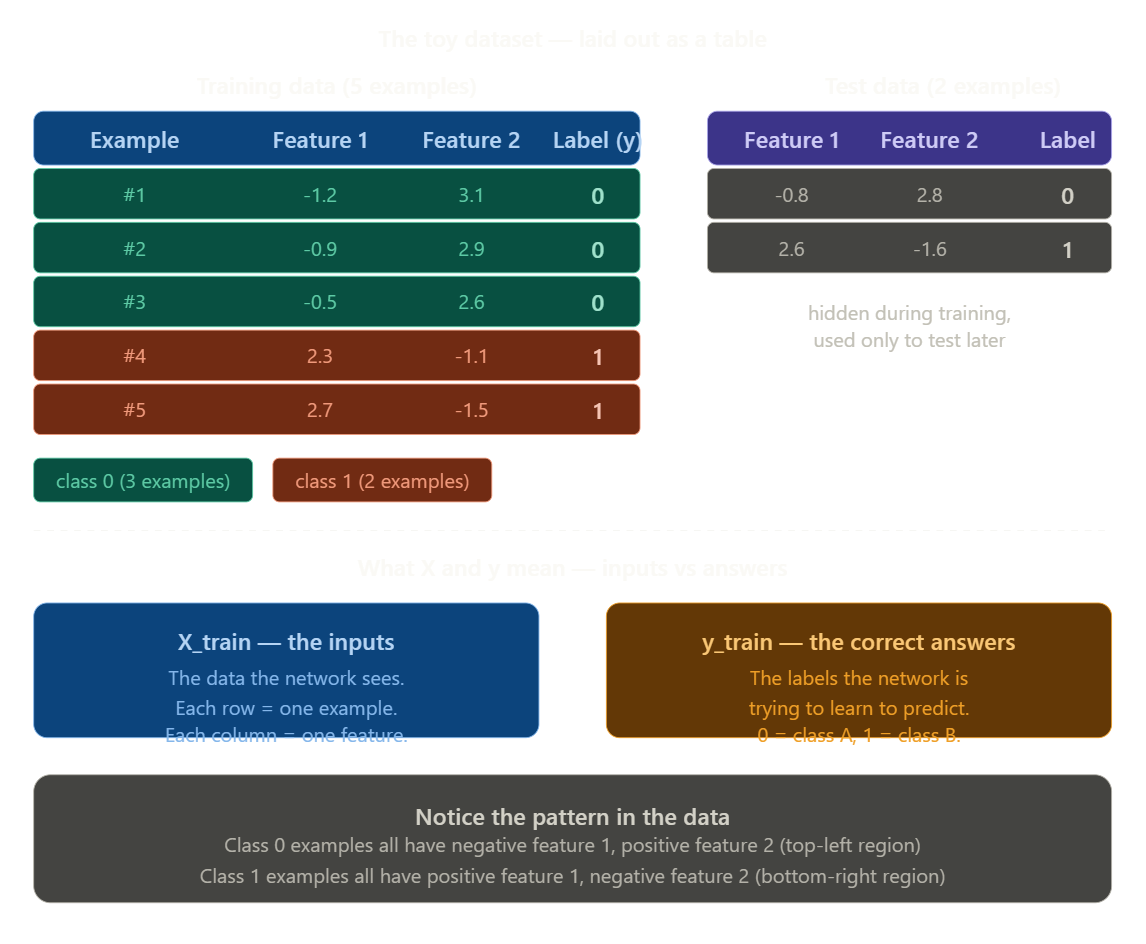

In [1]:
import torch 

X_train = torch.tensor([ # training data
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])

#target labels
#output nodes = 2 (0 or 1) 
y_train = torch.tensor([0,0,0,1,1])


#test data 
X_test = torch.tensor([
    [-0.8,2.8],
    [2.6, -1.6]
])

y_test = torch.tensor([0,1])

custom dataset

In [2]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        #saves X_train and y_train as attributes of the class
        self.features = X
        self.labels = y
    
    def __getitem__(self, index):
        #when called it returns the feature and corresponding label of the index passed to it
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y
    
    def __len__(self):
        #returns the number of samples in the dataset
        return self.labels.shape[0]
    
train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)


instantiating dataloader

In [6]:
from torch.utils.data import DataLoader

torch.manual_seed(123) #helps make the results reproducible by setting a seed for random number generation

train_loader = DataLoader(
    dataset=train_ds, #uses the train_ds dataset and functions as an iterator to loop through the dataset in batches
    batch_size=2, #feeding 2 examples at a time to the model
    shuffle=True, 
    num_workers=0, # number of subprocesses to use for data loading. 0 means the data will be loaded in the main process
    drop_last=True #if the number of samples in the dataset is not divisible by the batch size, the last batch will be dropped
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

#with the drop_last only 2 batches for 2 each the last with 1 is removed
for idx, (x,y) in enumerate(train_loader):
    print(f"Batch {idx} - X: {x}, y: {y}")


Batch 0 - X: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]), y: tensor([1, 0])
Batch 1 - X: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]), y: tensor([0, 0])
